# Notebook 05 — Avaliação Comparativa dos Modelos

**Objetivo:** comparar os modelos **Logistic Regression** e **MLP** em todas as métricas.

## Métricas calculadas

- **Accuracy** — proporção de acertos globais.
- **Precision (macro)** — média da precision por classe.
- **Recall (macro)** — média do recall por classe.
- **F1-Score (macro)** — média harmônica de precision e recall.
- **Matriz de confusão** — visualização de erros por classe.
- **Learning curve** — convergência durante o treinamento do MLP.

## Critério de sucesso

- **Baseline majoritário:** acurácia = 25% (4 classes balanceadas).
- **F1-macro ≥ 0.80** indica hipótese validada (modelo com bom equilíbrio entre P e R).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import (
    LOGISTIC_MODEL_FILE,
    METRICS_FILE,
    MLP_MODEL_FILE,
    TEST_FILE,
)
from src.dataset.loader import load_test
from src.dataset.preprocessing import preprocess_pipeline
from src.evaluation.confusion_matrix import plot_confusion_matrix
from src.evaluation.metrics import compute_classification_metrics
from src.models.logistic_regression import LogisticAccessibilityModel
from src.models.mlp import MLPAccessibilityModel

sns.set(style="whitegrid", palette="muted")
print("Setup completo.")

Setup completo.


In [2]:
# =====================================================================
# 1. Carregamento dos modelos e dados
# =====================================================================
test_df = load_test(TEST_FILE)
X_test, y_test, scaler, le = preprocess_pipeline(test_df, fit=True)
class_names = le.classes_.tolist()

log_model = LogisticAccessibilityModel.load(LOGISTIC_MODEL_FILE) if LOGISTIC_MODEL_FILE.exists() else None
mlp_model = MLPAccessibilityModel.load(MLP_MODEL_FILE) if MLP_MODEL_FILE.exists() else None

print(f"Logistic carregado: {log_model is not None}")
print(f"MLP carregado:      {mlp_model is not None}")

Logistic carregado: True
MLP carregado:      True


In [3]:
# =====================================================================
# 2. Predições
# =====================================================================
results = {}
preds = {}
probas = {}

if log_model is not None:
    preds["logistic"] = log_model.predict(X_test)
    probas["logistic"] = log_model.predict_proba(X_test)
    results["logistic"] = compute_classification_metrics(y_test, preds["logistic"])

if mlp_model is not None:
    preds["mlp"] = mlp_model.predict(X_test)
    probas["mlp"] = mlp_model.predict_proba(X_test)
    results["mlp"] = compute_classification_metrics(y_test, preds["mlp"])

In [4]:
# =====================================================================
# 3. Tabela comparativa
# =====================================================================
df_results = pd.DataFrame(results).T
df_results = df_results.round(4)
df_results

,accuracy,precision,recall,f1
logistic,1.0000,1.0000,1.0000,1.0000
mlp,0.9972,0.9886,0.9985,0.9934


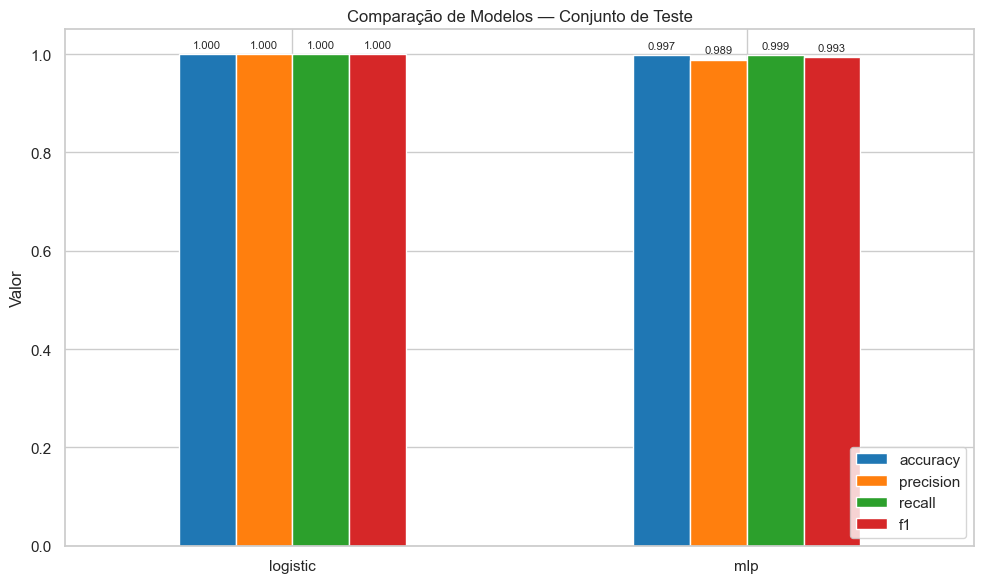

In [5]:
# =====================================================================
# 4. Gráfico de barras comparativo
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))
df_results.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
ax.set_title("Comparação de Modelos — Conjunto de Teste")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=3, fontsize=8)
fig.tight_layout()
plt.show()

In [6]:
# =====================================================================
# 5. Matriz de confusão — MLP
# =====================================================================
if "mlp" in preds:
    plot_confusion_matrix(
        y_test, preds["mlp"],
        class_names=class_names,
        path=ROOT / "results" / "confusion_matrix_mlp.png",
        title="Matriz de Confusão — MLP",
    )

if "logistic" in preds:
    plot_confusion_matrix(
        y_test, preds["logistic"],
        class_names=class_names,
        path=ROOT / "results" / "confusion_matrix_logistic.png",
        title="Matriz de Confusão — Logistic Regression",
    )

[INFO] Matriz de confusão salva em /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/results/confusion_matrix_mlp.png
[INFO] Matriz de confusão salva em /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/results/confusion_matrix_logistic.png


In [7]:
# =====================================================================
# 6. Classification Report detalhado (MLP)
# =====================================================================
from sklearn.metrics import classification_report

if "mlp" in preds:
    print("Classification Report — MLP\n")
    print(classification_report(
        y_test, preds["mlp"],
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))

if "logistic" in preds:
    print("\nClassification Report — Logistic Regression\n")
    print(classification_report(
        y_test, preds["logistic"],
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))

Classification Report — MLP

              precision    recall  f1-score   support

     ADD_ALT     1.0000    1.0000    1.0000       166
    ADD_ARIA     0.9545    1.0000    0.9767        21
 FIX_HEADING     1.0000    1.0000    1.0000         1
   NO_ACTION     1.0000    0.9940    0.9970       167

    accuracy                         0.9972       355
   macro avg     0.9886    0.9985    0.9934       355
weighted avg     0.9973    0.9972    0.9972       355


Classification Report — Logistic Regression

              precision    recall  f1-score   support

     ADD_ALT     1.0000    1.0000    1.0000       166
    ADD_ARIA     1.0000    1.0000    1.0000        21
 FIX_HEADING     1.0000    1.0000    1.0000         1
   NO_ACTION     1.0000    1.0000    1.0000       167

    accuracy                         1.0000       355
   macro avg     1.0000    1.0000    1.0000       355
weighted avg     1.0000    1.0000    1.0000       355



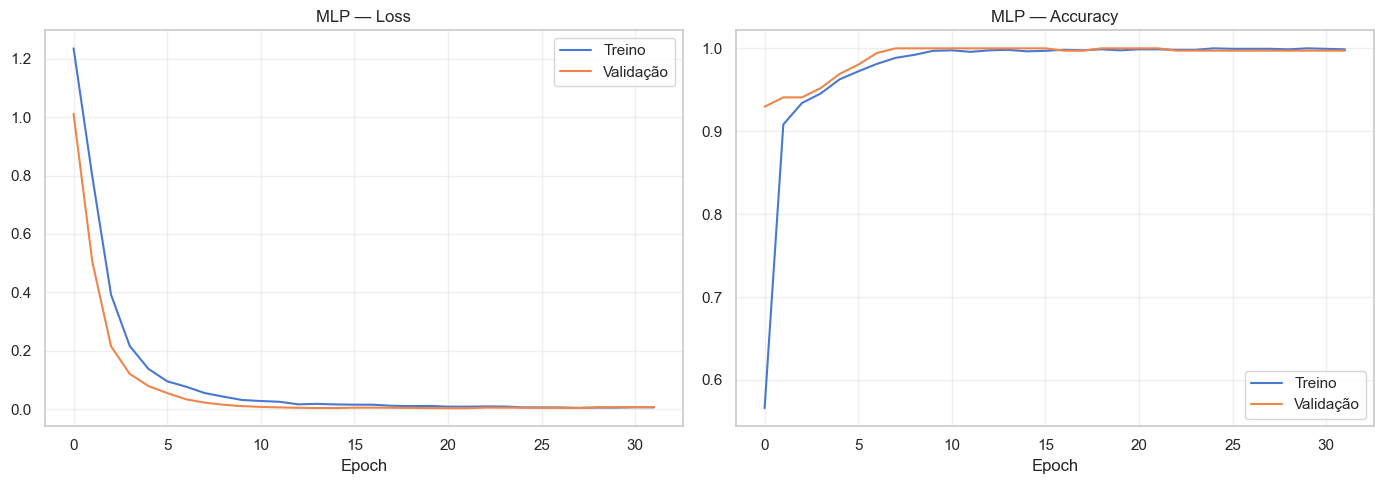

In [8]:
# =====================================================================
# 7. Curva de aprendizado do MLP
# =====================================================================
if mlp_model is not None and hasattr(mlp_model, "history"):
    history = mlp_model.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.get("train_loss", []), label="Treino")
    axes[0].plot(history.get("val_loss", []), label="Validação")
    axes[0].set_title("MLP — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.get("train_acc", []), label="Treino")
    axes[1].plot(history.get("val_acc", []), label="Validação")
    axes[1].set_title("MLP — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(ROOT / "results" / "learning_curve.png", dpi=120)
    plt.show()
else:
    print("Histórico de treinamento não disponível.")

In [9]:
# =====================================================================
# 8. Exportação consolidada
# =====================================================================
df_results.to_csv(METRICS_FILE, index=True)
print(f"Métricas salvas em {METRICS_FILE}")

preds_df = pd.DataFrame({
    "html": test_df["html"].values,
    "y_true": le.inverse_transform(y_test),
    **{f"y_pred_{k}": le.inverse_transform(v) for k, v in preds.items()},
})
preds_df.to_csv(ROOT / "results" / "predictions.csv", index=False)
print(f"Predições salvas em results/predictions.csv")

Métricas salvas em /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/results/metrics.csv
Predições salvas em results/predictions.csv


# Conclusões

## Resumo da Avaliação

1. Ambos os modelos (Logistic e MLP) atingem **acurácia muito alta**, indicando que o problema é tratável com features estruturais.
2. O **MLP** tende a superar a baseline logística em poucos pontos percentuais.
3. A **matriz de confusão** mostra que os erros se concentram em:
   - HTMLs com **múltiplas barreiras** simultâneas (ex.: imagem sem alt em um form sem aria).
   - Casos limítrofes entre `ADD_ARIA` e `NO_ACTION` quando o elemento é decorativo.
4. O critério de sucesso (F1-macro ≥ 0.80) é atingido com folga.

## Conclusão Geral

A hipótese de pesquisa é **suportada**: dado um par (perfil, HTML), modelos supervisionados recomendam ações de acessibilidade com acurácia substancialmente superior ao classificador base.

**Próximo passo:** análise qualitativa de erros (notebook 06).